In [1]:
import re
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [4]:
# Cell 3 — Load dataset

FILE_PATH = "./youtube-comment-dataset.csv"

df = pd.read_csv(FILE_PATH)

print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())

Shape: (45005, 14)
  channel_username                channel_id     video_id  \
0             @WWE  UCJ5v_MCY6GNUBTO8-D3XoAg  wj56SBaroCE   
1           @ZeeTV  UCppHT7SZKKvar4Oc9J4oljQ  3KWNKzs_ptQ   
2        @ColorsTV  UC55IWqFLDH1Xp7iu1_xknRA  eqwlbP4f4G4   
3       @김프로KIMPRO  UCiVs2pnGW5mLIc1jS2nxhjg  R_gAdQqH6gA   
4        @ColorsTV  UC55IWqFLDH1Xp7iu1_xknRA  g2pWwrK2fyE   

                                         video_title  \
0  Jade Cargill continues to perform knowing the ...   
1  Tum Se Tum Tak - तुम से तुम तक - 7th July Onwa...   
2  Laughter Chefs S2 | Full Episode - 41 | India ...   
3                   Perfect Featuring | First Take🎬🤣   
4  Meri Bhavya Life | Ep. 55 | Uma Requests Risha...   

                                        comment_text  \
0  Jade was pushed fast in another company. WWE i...   
1  Are ye 20 sal mushki se jiye ga tab ladki bewa...   
2  Aly is fcking rude for no reason its laughter ...   
3                     Aaaaaaaaaaaaaaaaaaaaaaaaaaaaaa 

In [5]:
# Cell 4 — Check columns

print("Columns:", df.columns.tolist())

Columns: ['channel_username', 'channel_id', 'video_id', 'video_title', 'comment_text', 'comment_id', 'author', 'published_at', 'like_count', 'reply_count', 'language', 'label_sentiment', 'label_toxicity', 'label_spam']


In [6]:
# Cell 5 — Select needed columns

TEXT_COL = "comment_text"   # change if needed
LABEL_COL = "label_sentiment"         # change if needed

df = df[[TEXT_COL, LABEL_COL]].copy()
df = df.dropna()

df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.lower()

print(df.head())
print(df[LABEL_COL].value_counts())

                                        comment_text label_sentiment
0  Jade was pushed fast in another company. WWE i...        positive
1  Are ye 20 sal mushki se jiye ga tab ladki bewa...         neutral
2  Aly is fcking rude for no reason its laughter ...         neutral
3                     Aaaaaaaaaaaaaaaaaaaaaaaaaaaaaa         neutral
4  bhavya is furfect maching rishank you don't mi...        negative
label_sentiment
neutral     22980
positive    18210
negative     3810
Name: count, dtype: int64


In [7]:
# Cell 6 — Clean text

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df[TEXT_COL] = df[TEXT_COL].apply(clean_text)

print(df.head())

                                        comment_text label_sentiment
0  jade was pushed fast in another company wwe is...        positive
1  are ye 20 sal mushki se jiye ga tab ladki bewa...         neutral
2  aly is fcking rude for no reason its laughter ...         neutral
3                     aaaaaaaaaaaaaaaaaaaaaaaaaaaaaa         neutral
4  bhavya is furfect maching rishank you don t mi...        negative


In [8]:
# Cell 7 — Label mapping

label_list = sorted(df[LABEL_COL].unique().tolist())
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

df["label_id"] = df[LABEL_COL].map(label2id)

print("Labels:", label_list)
print("Label mapping:", label2id)
print(df["label_id"].value_counts())

Labels: ['negative', 'neutral', 'positive']
Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
label_id
1    22980
2    18210
0     3810
Name: count, dtype: int64


In [9]:
# Cell 8 — Remove duplicates

before = len(df)
df = df.drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)
after = len(df)

print("Rows before:", before)
print("Rows after :", after)
print("Removed    :", before - after)

Rows before: 45000
Rows after : 36007
Removed    : 8993


In [10]:
# Cell 9 — Train / val / test split

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label_id"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label_id"],
    random_state=42
)

print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)

print("\nTrain label counts:")
print(train_df["label_id"].value_counts().sort_index())

print("\nVal label counts:")
print(val_df["label_id"].value_counts().sort_index())

print("\nTest label counts:")
print(test_df["label_id"].value_counts().sort_index())

Train shape: (28805, 3)
Val shape  : (3601, 3)
Test shape : (3601, 3)

Train label counts:
label_id
0     2810
1    15292
2    10703
Name: count, dtype: int64

Val label counts:
label_id
0     351
1    1912
2    1338
Name: count, dtype: int64

Test label counts:
label_id
0     351
1    1912
2    1338
Name: count, dtype: int64


In [11]:
# Cell 10 — Model choice

MODEL_NAME = "xlm-roberta-base"   # change if you want a different model

In [12]:
# Cell 11 — Load tokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded


In [13]:
# Cell 12 — Convert to Dataset

train_dataset = Dataset.from_pandas(
    train_df[[TEXT_COL, "label_id"]].rename(columns={"label_id": "labels"})
)
val_dataset = Dataset.from_pandas(
    val_df[[TEXT_COL, "label_id"]].rename(columns={"label_id": "labels"})
)
test_dataset = Dataset.from_pandas(
    test_df[[TEXT_COL, "label_id"]].rename(columns={"label_id": "labels"})
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['comment_text', 'labels', '__index_level_0__'],
    num_rows: 28805
})
Dataset({
    features: ['comment_text', 'labels', '__index_level_0__'],
    num_rows: 3601
})
Dataset({
    features: ['comment_text', 'labels', '__index_level_0__'],
    num_rows: 3601
})


In [14]:
# Cell 13 — Tokenize dataset

def tokenize_function(example):
    return tokenizer(
        example[TEXT_COL],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print("Tokenization complete")

Map:   0%|          | 0/28805 [00:00<?, ? examples/s]

Map:   0%|          | 0/3601 [00:00<?, ? examples/s]

Map:   0%|          | 0/3601 [00:00<?, ? examples/s]

Tokenization complete


In [15]:
# Cell 14 — Load model

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

print("Model loaded")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded


In [16]:
# Cell 15 — Check device

print("CUDA available:", torch.cuda.is_available())
print("Has XPU attr:", hasattr(torch, "xpu"))
print("XPU available:", hasattr(torch, "xpu") and torch.xpu.is_available())

if hasattr(torch, "xpu") and torch.xpu.is_available():
    device = torch.device("xpu")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

model.to(device)

CUDA available: True
Has XPU attr: True
XPU available: False
Using device: cuda


XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=3, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [17]:
# Cell 16 — Metrics

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")

    return {
        "accuracy": acc,
        "f1": macro_f1
    }

In [18]:
# Cell 17 — Training arguments (XPU safe)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    optim="adamw_torch",
    fp16=False,
    bf16=False
)

In [19]:
# Cell 18 — Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Trainer ready")

Trainer ready


In [20]:
# Cell 19 — Train model

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.760356,0.694730,0.723410,0.675887
2,0.673588,0.685668,0.727576,0.682248
3,0.622035,0.682470,0.740905,0.700938
4,0.576022,0.686104,0.743405,0.706817
5,0.528466,0.745071,0.722299,0.693668
6,0.485212,0.825427,0.710914,0.690173
7,0.447714,0.866234,0.724521,0.696741
8,0.413178,0.981742,0.713413,0.689873


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=28808, training_loss=0.5633213728608373, metrics={'train_runtime': 9014.494, 'train_samples_per_second': 25.563, 'train_steps_per_second': 3.196, 'total_flos': 1.515796399531008e+16, 'train_loss': 0.5633213728608373, 'epoch': 8.0})

In [21]:
# Cell 20 — Evaluate on test set

test_results = trainer.predict(test_dataset)

logits = test_results.predictions
labels = test_results.label_ids
preds = np.argmax(logits, axis=-1)

acc = accuracy_score(labels, preds)
macro_f1 = f1_score(labels, preds, average="macro")

print("Accuracy:", acc)
print("Macro F1:", macro_f1)

Accuracy: 0.7267425715079144
Macro F1: 0.6937617546884379


In [22]:
# Cell 21 — Inspect wrong predictions

pred_texts = test_df[TEXT_COL].tolist()

results_df = pd.DataFrame({
    "text": pred_texts,
    "true_label": [id2label[i] for i in labels],
    "pred_label": [id2label[i] for i in preds]
})

wrong_df = results_df[results_df["true_label"] != results_df["pred_label"]]

print("Total wrong predictions:", len(wrong_df))
print(wrong_df.head(20))

Total wrong predictions: 984
                                                 text true_label pred_label
1   iqoo neo 10 focuses on gaming only but gt 7 fo...   positive    neutral
6                    namma bengalore team forever rcb    neutral   positive
21        nithanada kelapiii vitaaa trump dvd payaley   positive    neutral
24                                               2024   positive    neutral
28                 jennie rosé and lisa are but jisoo   negative   positive
29                                              2 ped   positive    neutral
32  एक ब टल 500ml gm क ऐस एक ब क स म 40 ब टल य न 2...   negative    neutral
36             bhai ata na jata gyan pelu bahut jyada   positive    neutral
39               please trim down this annoying music   positive    neutral
43                                 bts army র স র দ ও    neutral   positive
49                                              31 56   positive    neutral
55  his friend adani is in the grip of trump for f...   pos

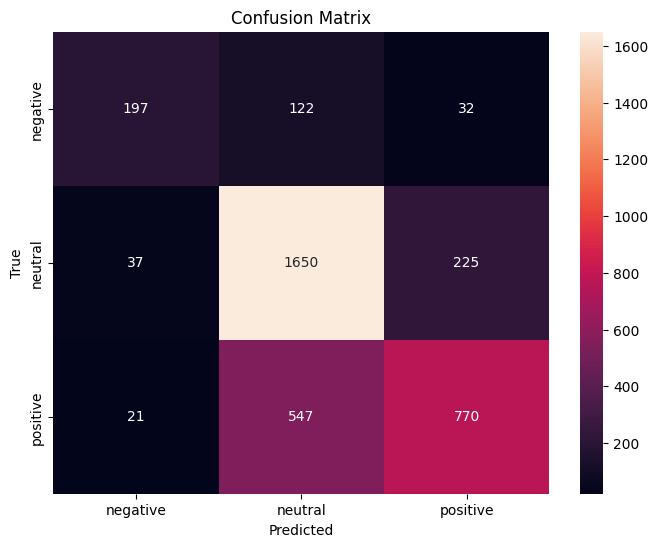

In [23]:
# Cell 22 — Confusion matrix

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_list, yticklabels=label_list)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [24]:
# Cell 23 — Save model

trainer.save_model("./youtube_toxic_comment_model")
tokenizer.save_pretrained("./youtube_toxic_comment_model")

print("Model saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved


In [25]:
# Cell 24 — Prediction function

def predict_toxic_class(text):
    model.eval()

    cleaned = clean_text(text)

    inputs = tokenizer(
        cleaned,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        pred_id = torch.argmax(outputs.logits, dim=1).item()

    return id2label[pred_id]

In [27]:
# Cell 25 — Manual tests

test_texts = [
    "You are disgusting",
    "I will destroy you",
    "You are an idiot",
    "This trash content is awful",
    "I hate you so much",
    "kam korosna abar kotha bolos"
]

for text in test_texts:
    print(f"{text} -> {predict_toxic_class(text)}")

You are disgusting -> negative
I will destroy you -> negative
You are an idiot -> negative
This trash content is awful -> negative
I hate you so much -> negative
kam korosna abar kotha bolos -> neutral
